In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

In [2]:
from datetime import date
df = yf.download("GC=F",start = "2015-01-01", end = date.today())

[*********************100%***********************]  1 of 1 completed


In [3]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2026-06-26,4078.699951,4078.699951,4078.699951,4078.699951,1431
2026-06-29,4022.300049,4070.000000,4003.199951,4057.500000,785
2026-06-30,4022.899902,4049.699951,3962.500000,4002.600098,1108
2026-07-01,4068.300049,4100.000000,3963.000000,4013.100098,770
2026-07-02,4112.700195,4140.100098,4062.000000,4067.500000,770


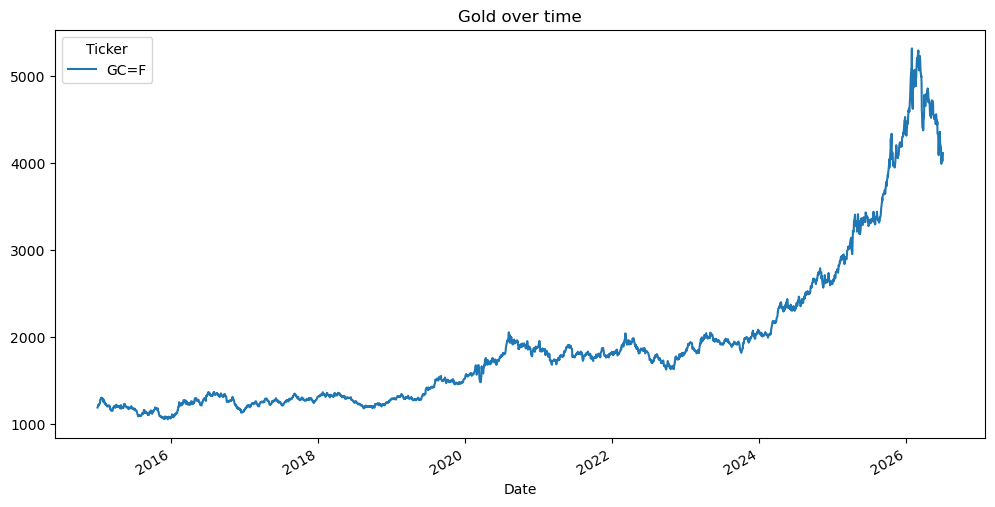

In [4]:
df["Close"].plot(figsize=(12,6),title="Gold over time")
plt.show()

In [5]:
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA21"] = df["Close"].rolling(window=21).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()
df["Daily_return"] = df["Close"].pct_change()
df["Price_position"] = (df["Close"] - df["Low"]) / (df["High"] - df["Low"])
df["HL_diff"] = df["High"] - df["Low"]
df["OC_diff"] = df["Open"] - df["Close"]


In [6]:
df.tail(10)

Price,Close,High,Low,Open,Volume,MA7,MA21,MA50,Daily_return,Price_position,HL_diff,OC_diff
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,,,,,,,
Date,,,,,,,,,,,,
2026-06-18,4224.100098,4323.200195,4223.700195,4279.799805,738,4236.485735,4384.047607,4558.303989,-0.030925,0.004019,99.500000,55.699707
2026-06-22,4181.899902,4216.399902,4134.799805,4138.799805,1197,4247.014265,4367.409517,4546.097983,-0.009990,0.577206,81.600098,-43.100098
2026-06-23,4129.899902,4135.200195,4118.500000,4127.100098,252,4252.671387,4347.890474,4533.457983,-0.012435,0.682621,16.700195,-2.799805
2026-06-24,3990.300049,4104.700195,3963.300049,4104.399902,353,4220.571394,4322.619048,4518.415986,-0.033802,0.190947,141.400146,114.099854
2026-06-25,4030.500000,4030.500000,3986.699951,3988.399902,2724,4178.071394,4300.242862,4502.525986,0.010074,1.000000,43.800049,-42.100098
2026-06-26,4078.699951,4078.699951,4078.699951,4078.699951,1431,4142.042829,4282.680955,4488.099985,0.011959,NaN,0.000000,0.000000
2026-06-29,4022.300049,4070.000000,4003.199951,4057.500000,785,4093.957136,4259.966681,4472.837988,-0.013828,0.285929,66.800049,35.199951
2026-06-30,4022.899902,4049.699951,3962.500000,4002.600098,1108,4065.214251,4234.366676,4456.143984,0.000149,0.692660,87.199951,-20.299805


In [7]:
df["Target"] = (df["Close"].shift(-1)>df["Close"]).astype(int)

In [8]:
df[["Close","Target"]].tail(10)

Price,Close,Target
Ticker,GC=F,
Date,,
2026-06-18,4224.100098,0
2026-06-22,4181.899902,0
2026-06-23,4129.899902,0
2026-06-24,3990.300049,1
2026-06-25,4030.500000,1
2026-06-26,4078.699951,0
2026-06-29,4022.300049,1
2026-06-30,4022.899902,1


In [9]:
df.isnull().sum()
df.shape

(2890, 13)

In [10]:
df["Price_position"] = df["Price_position"].fillna(0.5)

In [11]:
df = df.dropna()
df.isnull().sum()
df.shape

(2841, 13)

In [12]:
X = df[["MA7","MA21","MA50","Daily_return","Price_position","HL_diff","OC_diff"]]
Y = df["Target"]

In [13]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

Y_train = Y[:split]
Y_test = Y[split:]


In [14]:
model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [15]:
Y_pred = model.predict(X_test)
"Accuracy:",accuracy_score(Y_test,Y_pred)

('Accuracy:', 0.5536028119507909)

In [16]:
model = XGBClassifier(n_estimators=200,
                      learning_rate=0.01,
                      max_depth=3,
                      random_state=42)
model.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [17]:
Y_pred = model.predict(X_test)
"Accuracy:",accuracy_score(Y_test,Y_pred)

('Accuracy:', 0.5711775043936731)

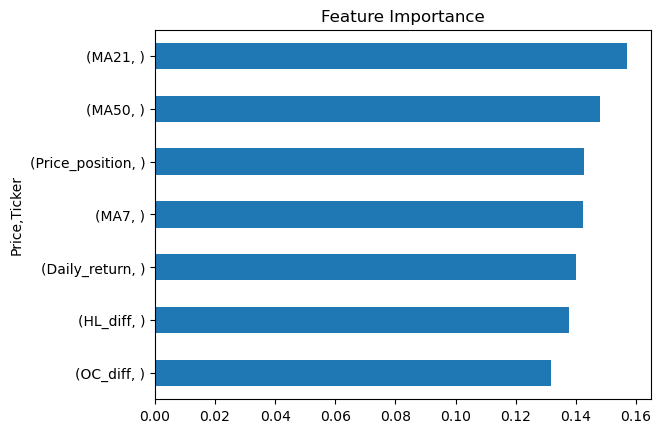

In [18]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()